# Deepfake Detection — Data Pipeline

**Goal:** Convert raw `.mp4` videos into clean face images for CNN training.

## Pipeline Overview
```
Raw videos (MP4)  [01_raw_videos/]
      ↓  Step 1: Extract frames (every N frames)
Video frames (JPG)  [02_frames/]
      ↓  Step 2: Detect and crop faces
Face images (JPG, 224×224)  [03_faces/]
      ↓  Step 3: Split into train / val / test
Organised folders  [04_dataset/]
      ↓  Step 4: Build PyTorch DataLoader
DataLoader
```

## Notebook Sections
1. Import Libraries
2. Set Up Local Paths
3. Explore the Dataset
4. Extract Frames from Videos
5. Detect and Crop Faces
6. Split into Train / Val / Test
7. Build PyTorch DataLoader
8. Verify and Save DataLoader Info

---
## Section 1: Import Libraries

Install any missing packages with:
```
pip install facenet-pytorch tqdm opencv-python torch torchvision
```

In [1]:
# ── Standard library imports ────────────────────────────────────────────
import os
import shutil
import random
import json
from pathlib import Path

# ── Third-party imports ──────────────────────────────────────────────────
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

# ── Face detection ───────────────────────────────────────────────────────
from facenet_pytorch import MTCNN

# ── PyTorch imports ──────────────────────────────────────────────────────
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print("All libraries imported successfully.")
print(f"   PyTorch version : {torch.__version__}")
print(f"   GPU available   : {torch.cuda.is_available()}")

All libraries imported successfully.
   PyTorch version : 2.13.0.dev20260506+cu130
   GPU available   : True


---
## Section 2: Set Up Local Paths

All data lives inside the project folder next to this notebook.
The cell below defines every path used throughout the pipeline.

In [2]:
# Project root = the folder that contains this notebook
# Path.cwd() returns that folder when Jupyter is launched from it.
PROJECT_ROOT = Path.cwd()

RAW_DIR     = PROJECT_ROOT / '01_raw_videos'   # original .mp4 files
FRAMES_DIR  = PROJECT_ROOT / '02_frames'       # extracted video frames
FACES_DIR   = PROJECT_ROOT / '03_faces'        # cropped face images
DATASET_DIR = PROJECT_ROOT / '04_dataset'      # final train/val/test

for folder in [RAW_DIR, FRAMES_DIR, FACES_DIR, DATASET_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders ready.")
print(f"   Project root : {PROJECT_ROOT}")

Project folders ready.
   Project root : C:\Users\lulum\Documents\umbc\DATA 621\Final Project


---
## Section 3: Explore the Dataset

Before processing, we check what we are working with:
average video length, FPS, and resolution.
This helps us pick good values for the frame-extraction settings.

In [3]:
REAL_VIDEO_DIR = RAW_DIR / 'DFD_original sequences'
FAKE_VIDEO_DIR = RAW_DIR / 'DFD_manipulated_sequences'

real_videos = list(REAL_VIDEO_DIR.rglob('*.mp4'))
fake_videos = list(FAKE_VIDEO_DIR.rglob('*.mp4'))

print(f"Real (original) videos : {len(real_videos)}")
print(f"Fake (deepfake) videos : {len(fake_videos)}")
print(f"Total                  : {len(real_videos) + len(fake_videos)}")

Real (original) videos : 363
Fake (deepfake) videos : 3068
Total                  : 3431


In [4]:
def get_video_info(video_path: Path) -> dict:
    cap = cv2.VideoCapture(str(video_path))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps         = cap.get(cv2.CAP_PROP_FPS)
    width       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration    = frame_count / fps if fps > 0 else 0
    cap.release()
    return {'frame_count': frame_count, 'fps': fps,
            'width': width, 'height': height, 'duration_s': duration}


sample_size = min(10, len(real_videos), len(fake_videos))
sample_real = random.sample(real_videos, sample_size)
sample_fake = random.sample(fake_videos, sample_size)

real_info = [get_video_info(v) for v in sample_real]
fake_info = [get_video_info(v) for v in sample_fake]

for label, info_list in [('Real', real_info), ('Fake', fake_info)]:
    avg_fps      = np.mean([i['fps']         for i in info_list])
    avg_frames   = np.mean([i['frame_count'] for i in info_list])
    avg_duration = np.mean([i['duration_s']  for i in info_list])
    resolution   = f"{info_list[0]['width']}×{info_list[0]['height']}"
    print(f"{label} videos (sample of {sample_size}):")
    print(f"   Average FPS      : {avg_fps:.1f}")
    print(f"   Average frames   : {avg_frames:.0f}")
    print(f"   Average duration : {avg_duration:.1f} seconds")
    print(f"   Resolution       : {resolution}")
    print()

Real videos (sample of 10):
   Average FPS      : 24.0
   Average frames   : 888
   Average duration : 37.0 seconds
   Resolution       : 1920×1080

Fake videos (sample of 10):
   Average FPS      : 24.0
   Average frames   : 682
   Average duration : 28.4 seconds
   Resolution       : 1920×1080



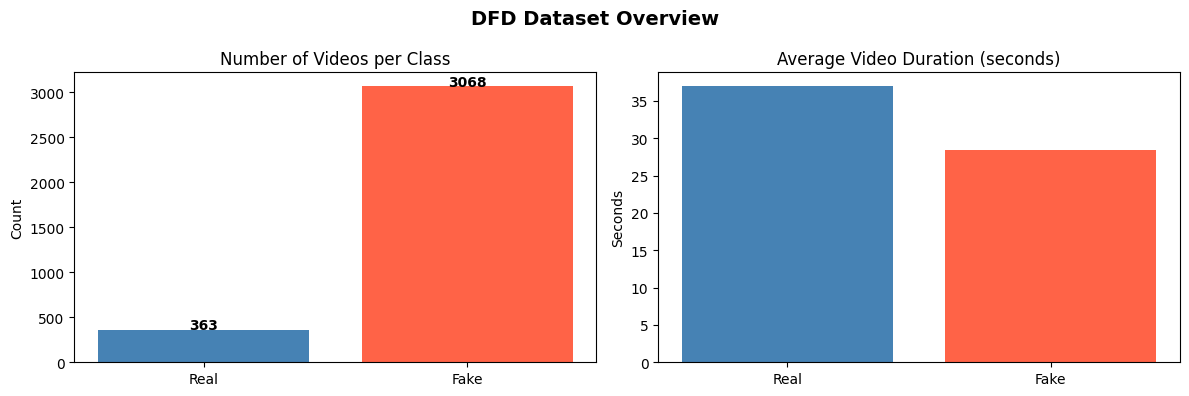

Chart saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Real', 'Fake'], [len(real_videos), len(fake_videos)],
            color=['steelblue', 'tomato'])
axes[0].set_title('Number of Videos per Class')
axes[0].set_ylabel('Count')
for i, val in enumerate([len(real_videos), len(fake_videos)]):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold')

avg_real_dur = np.mean([i['duration_s'] for i in real_info])
avg_fake_dur = np.mean([i['duration_s'] for i in fake_info])
axes[1].bar(['Real', 'Fake'], [avg_real_dur, avg_fake_dur],
            color=['steelblue', 'tomato'])
axes[1].set_title('Average Video Duration (seconds)')
axes[1].set_ylabel('Seconds')

plt.suptitle('DFD Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'dataset_overview.png'), dpi=150)
plt.show()
print("Chart saved.")

---
## Section 4: Extract Frames from Videos

A video is just many images played quickly one after another.
We pull out individual images ('frames') from each video.

**Key setting — `FRAMES_PER_SECOND`:**
- If a video is 30 FPS and we set `FRAMES_PER_SECOND = 1`, we take 1 frame every second.
- This gives enough variety without creating millions of nearly identical images.

> **Skip this section** if `02_frames/` is already populated.

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
# How many frames to extract per second of video
# (1 = one frame per second, which is usually enough for training)
FRAMES_PER_SECOND = 1

# Maximum frames to extract per video
# This prevents very long videos from dominating the dataset
MAX_FRAMES_PER_VIDEO = 30


def extract_frames(
    video_path: Path,
    output_dir: Path,
    fps_target: int = 1,
    max_frames: int = 30,
) -> int:
    """
    Extract frames from a single video file and save them as JPEG images.

    We only extract a frame every (video_fps / fps_target) frames.
    For example, a 30 FPS video with fps_target=1 extracts every 30th frame.

    Args:
        video_path : Path to the .mp4 video file.
        output_dir : Folder where extracted frames will be saved.
        fps_target : How many frames to extract per second of video.
        max_frames : Stop after extracting this many frames.

    Returns:
        The number of frames that were actually saved.
    """
    output_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    video_fps = cap.get(cv2.CAP_PROP_FPS)

    # How many frames to skip between each save
    # Example: video is 30 FPS, we want 1 FPS → skip every 30 frames
    frame_interval = max(1, int(round(video_fps / fps_target)))

    frame_index  = 0   # Total frames read so far
    saved_count  = 0   # Total frames saved so far

    while cap.isOpened():
        ret, frame = cap.read()

        # ret is False when we reach the end of the video
        if not ret:
            break

        # Only save every Nth frame based on our interval
        if frame_index % frame_interval == 0:
            frame_filename = output_dir / f"frame_{saved_count:04d}.jpg"
            cv2.imwrite(str(frame_filename), frame)
            saved_count += 1

        # Stop if we have already extracted enough frames from this video
        if saved_count >= max_frames:
            break

        frame_index += 1

    cap.release()
    return saved_count


print("✅ extract_frames() function is ready.")

In [ ]:
def batch_extract_frames(
    video_list: list,
    label: str,
    output_root: Path,
    fps_target: int = 1,
    max_frames: int = 30,
) -> None:
    """
    Extract frames from a list of videos and organise them by video name.

    Output structure:
        output_root/
            real/
                video_001/frame_0000.jpg
                video_001/frame_0001.jpg
                ...
            fake/
                video_001/frame_0000.jpg
                ...

    Args:
        video_list  : List of Path objects pointing to video files.
        label       : Either 'real' or 'fake'.
        output_root : Root folder where frames are saved.
        fps_target  : Frames to extract per second.
        max_frames  : Maximum frames per video.
    """
    total_saved = 0

    for video_path in tqdm(video_list, desc=f"Extracting {label} frames"):
        # Each video gets its own sub-folder, named after the video file
        video_name  = video_path.stem   # File name without the .mp4 extension
        output_dir  = output_root / label / video_name

        saved = extract_frames(
            video_path=video_path,
            output_dir=output_dir,
            fps_target=fps_target,
            max_frames=max_frames,
        )
        total_saved += saved

    print(f"✅ {label.capitalize()}: extracted {total_saved} frames total.")


# Run frame extraction for both real and fake videos

# --- TEST MODE (uses only 20 videos per class — uncomment to test quickly) ---
# real_videos_to_process = real_videos[:20]
# fake_videos_to_process = fake_videos[:20]

# --- FULL MODE (processes all videos) ---
real_videos_to_process = real_videos
fake_videos_to_process = fake_videos

batch_extract_frames(
    video_list=real_videos_to_process,
    label="real",
    output_root=FRAMES_DIR,
    fps_target=FRAMES_PER_SECOND,
    max_frames=MAX_FRAMES_PER_VIDEO,
)

batch_extract_frames(
    video_list=fake_videos_to_process,
    label="fake",
    output_root=FRAMES_DIR,
    fps_target=FRAMES_PER_SECOND,
    max_frames=MAX_FRAMES_PER_VIDEO,
)

---
## Section 6: Detect and Crop Faces

A video frame contains the full image — background, body, etc.
We only want the **face** part, because that is what the CNN needs to learn from.

We use **MTCNN** (Multi-Task Cascaded Convolutional Network), which is a small model
that finds the bounding box (rectangle) around each face in an image.

**Output size: 224×224 pixels** — this is the standard input size for models like ResNet and EfficientNet.

In [6]:
# Create the MTCNN face detector
# - image_size=224: resize the cropped face to 224×224 pixels
# - margin=20: add a small border around the face so we don't cut it too tightly
# - keep_all=False: only keep the largest (most prominent) face per image

BATCH_SIZE_MTCNN = 32

# - device: use the GPU if available, otherwise use the CPU
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

face_detector = MTCNN(
    image_size=224,
    margin=20,
    keep_all=False,
    device=DEVICE,
    post_process=False,   # Return pixel values in range [0, 255], not normalised
)

print(f"✅ MTCNN face detector loaded on: {DEVICE}")

✅ MTCNN face detector loaded on: cuda


In [7]:
def crop_face_from_image(image_path: Path, output_path: Path) -> bool:
    """
    Detect the face in one image and save the cropped face as a new file.

    Steps:
      1. Open the image.
      2. Ask MTCNN to find the face location.
      3. If a face is found, save the cropped face tensor as a JPEG.
      4. If no face is found, skip this image.

    Args:
        image_path  : Path to the input frame image.
        output_path : Where to save the cropped face.

    Returns:
        True if a face was found and saved, False otherwise.
    """
    try:
        img = Image.open(image_path).convert("RGB")

        # face_tensor will be a 3D array of shape (3, 224, 224) if a face is found,
        # or None if no face was detected
        face_tensor = face_detector(img)

        if face_tensor is None:
            # No face found in this image — skip it
            return False

        # Convert the tensor back to a regular image and save it
        # The tensor values are in range [0, 255] so we clamp and convert to uint8
        face_array = np.clip(face_tensor.permute(1, 2, 0).numpy(), 0, 255).astype(np.uint8)
        face_image = Image.fromarray(face_array)

        output_path.parent.mkdir(parents=True, exist_ok=True)
        face_image.save(str(output_path), format="JPEG", quality=95)
        return True

    except Exception as error:
        # If something goes wrong with one image, just skip it and move on
        print(f"   ⚠️  Skipped {image_path.name}: {error}")
        return False


print("✅ crop_face_from_image() function is ready.")

✅ crop_face_from_image() function is ready.


In [8]:
from facenet_pytorch import extract_face as _extract_face

def batch_crop_faces_fast(
    label: str,
    frames_root: Path,
    faces_root: Path,
    batch_size: int = 32,
) -> dict:
    """
    Crop faces from all frames using batched MTCNN detection.

    We call face_detector.detect() for batched bounding-box detection (GPU-
    efficient), then use extract_face() to crop each image individually.

    Calling face_detector(batch) with keep_all=False crashes when some images
    have no face because facenet-pytorch tries np.array(mixed_None_list), which
    raises a ValueError for inhomogeneous shapes. Using detect() avoids this.

    Args:
        label       : Either 'real' or 'fake'.
        frames_root : Root folder where extracted frames are stored.
        faces_root  : Root folder where cropped faces will be saved.
        batch_size  : How many images to send to the GPU at once for detection.

    Returns:
        A dictionary with statistics about the process.
    """
    all_frames = sorted((frames_root / label).rglob("*.jpg"))
    found     = 0
    not_found = 0

    batches = [
        all_frames[i : i + batch_size]
        for i in range(0, len(all_frames), batch_size)
    ]

    for batch_paths in tqdm(batches, desc=f"Cropping {label} faces (batched)"):

        # Skip frames already processed (allows safe resume)
        batch_paths = [
            p for p in batch_paths
            if not (faces_root / p.relative_to(frames_root)).exists()
        ]
        if not batch_paths:
            continue

        # ── Step 1: Load images ───────────────────────────────────────────
        pil_images = []
        for path in batch_paths:
            try:
                pil_images.append(Image.open(path).convert("RGB"))
            except Exception:
                pil_images.append(Image.new("RGB", (224, 224)))

        # ── Step 2: Batch bounding-box detection (GPU-efficient) ──────────
        # detect() returns (boxes_list, probs_list).
        # Each element is None (no face) or ndarray of shape (N, 4).
        # This does NOT trigger the inhomogeneous-array crash.
        try:
            boxes_list, probs_list = face_detector.detect(pil_images)
        except Exception as err:
            print(f"   ⚠️  Batch detect failed: {err} — skipping batch")
            not_found += len(batch_paths)
            continue

        # ── Step 3: Crop and save one face per frame ──────────────────────
        for frame_path, img, boxes, probs in zip(
            batch_paths, pil_images, boxes_list, probs_list
        ):
            if boxes is None or len(boxes) == 0:
                not_found += 1
                continue

            # Pick the face with the highest detection confidence
            best_idx = int(np.argmax(probs))
            best_box = boxes[best_idx]

            try:
                # extract_face crops the face region, resizes to image_size,
                # and returns a float32 tensor of shape (3, H, W) in [0, 255]
                face_tensor = _extract_face(img, best_box, image_size=224, margin=20)
                face_array  = np.clip(
                    face_tensor.permute(1, 2, 0).numpy(), 0, 255
                ).astype(np.uint8)
            except Exception as err:
                print(f"   ⚠️  extract_face failed for {frame_path.name}: {err}")
                not_found += 1
                continue

            relative_path = frame_path.relative_to(frames_root)
            output_path   = faces_root / relative_path
            output_path.parent.mkdir(parents=True, exist_ok=True)
            Image.fromarray(face_array).save(str(output_path), format="JPEG", quality=95)
            found += 1

    stats = {
        "label"       : label,
        "total_frames": len(all_frames),
        "faces_found" : found,
        "faces_missed": not_found,
        "success_rate": found / len(all_frames) * 100 if all_frames else 0,
    }
    print(f"✅ {label.capitalize()}: {found}/{len(all_frames)} faces found "
          f"({stats['success_rate']:.1f}% success rate)")
    return stats


# ── Run batched face cropping ──────────────────────────────────────────────────
real_stats = batch_crop_faces_fast("real", FRAMES_DIR, FACES_DIR, BATCH_SIZE_MTCNN)
fake_stats = batch_crop_faces_fast("fake", FRAMES_DIR, FACES_DIR, BATCH_SIZE_MTCNN)

print("\n📊 Face Cropping Summary:")
print(f"   Real faces saved: {real_stats['faces_found']}")
print(f"   Fake faces saved: {fake_stats['faces_found']}")

Cropping real faces (batched):   0%|          | 0/319 [00:00<?, ?it/s]

✅ Real: 9594/10197 faces found (94.1% success rate)


Cropping fake faces (batched):   0%|          | 0/2251 [00:00<?, ?it/s]

✅ Fake: 71924/72031 faces found (99.9% success rate)

📊 Face Cropping Summary:
   Real faces saved: 9594
   Fake faces saved: 71924


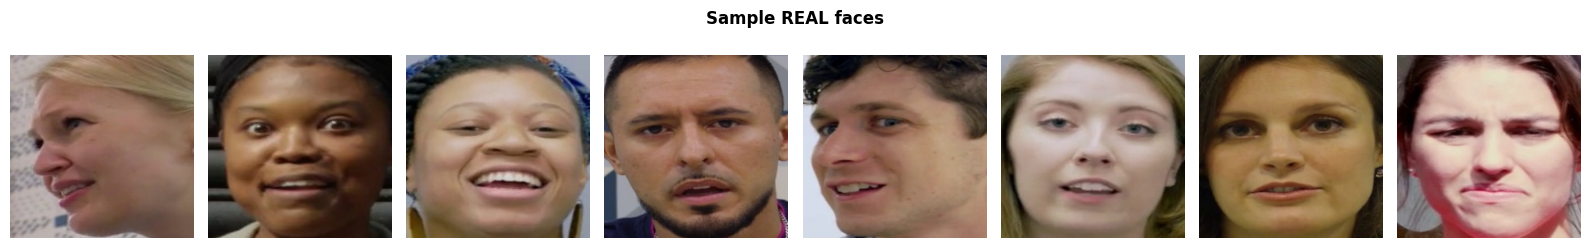

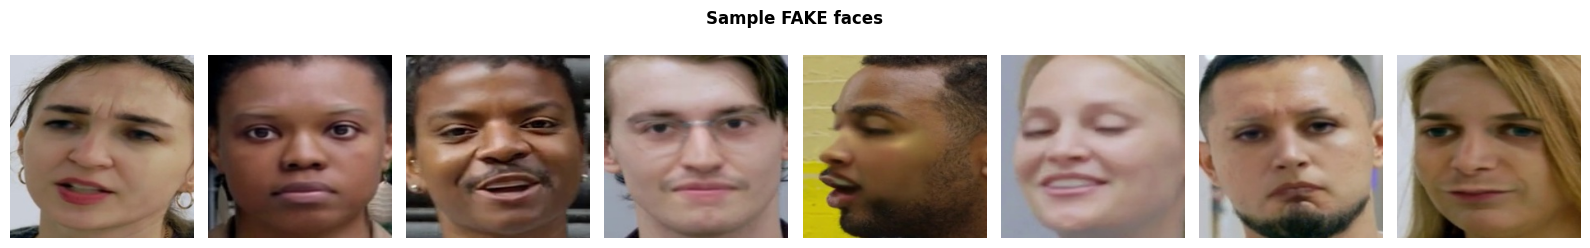

In [9]:
# ── Visual check: show a few sample faces from each class ─────────────────────
def show_sample_faces(label: str, faces_root: Path, num_samples: int = 8) -> None:
    """
    Display a grid of sample face images so we can visually verify the results.

    Args:
        label       : Either 'real' or 'fake'.
        faces_root  : Root folder containing cropped faces.
        num_samples : How many sample images to show.
    """
    all_faces = list((faces_root / label).rglob("*.jpg"))
    samples   = random.sample(all_faces, min(num_samples, len(all_faces)))

    fig, axes = plt.subplots(1, len(samples), figsize=(2 * len(samples), 2.5))
    fig.suptitle(f"Sample {label.upper()} faces", fontsize=12, fontweight="bold")

    for ax, face_path in zip(axes, samples):
        img = Image.open(face_path)
        ax.imshow(img)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(str(PROJECT_ROOT / f"sample_{label}_faces.png"), dpi=150)
    plt.show()


show_sample_faces("real", FACES_DIR)
show_sample_faces("fake", FACES_DIR)

---
## Section 7: Split into Train / Val / Test

We split our face images into three groups:

| Split | Purpose | Percentage |
|-------|---------|------------|
| **Train** | The model learns from these images | 70% |
| **Val** | We check if the model is improving during training | 15% |
| **Test** | Final evaluation — never touched during training | 15% |

**Important rule:** We split by **video**, not by individual frame.
If frames from the same video end up in both train and test, the model might
just memorize that video instead of learning general features.
This is called **data leakage** and it makes our results look better than they really are.

In [10]:
# ── Configuration ─────────────────────────────────────────────────────────────
TRAIN_RATIO = 0.70   # 70% of videos go to train
VAL_RATIO   = 0.15   # 15% go to val
TEST_RATIO  = 0.15   # 15% go to test
RANDOM_SEED = 42     # Fixed seed so the split is the same every time we run this

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6, \
    "Train + val + test ratios must add up to 1.0"


def split_videos_by_ratio(
    video_names: list,
    train_ratio: float,
    val_ratio: float,
    seed: int = 42,
) -> tuple[list, list, list]:
    """
    Randomly split a list of video names into train, val, and test groups.

    We split the video names (not the individual frames) to prevent data leakage.

    Args:
        video_names : List of video folder names (one per video).
        train_ratio : Fraction of videos for training.
        val_ratio   : Fraction of videos for validation.
        seed        : Random seed for reproducibility.

    Returns:
        Three lists: (train_names, val_names, test_names)
    """
    random.seed(seed)
    shuffled = video_names.copy()
    random.shuffle(shuffled)

    n        = len(shuffled)
    n_train  = int(n * train_ratio)
    n_val    = int(n * val_ratio)

    train_names = shuffled[:n_train]
    val_names   = shuffled[n_train : n_train + n_val]
    test_names  = shuffled[n_train + n_val :]

    return train_names, val_names, test_names


def copy_faces_to_dataset(
    video_names: list,
    split_name: str,
    label: str,
    faces_root: Path,
    dataset_root: Path,
) -> int:
    """
    Copy face images from one set of videos into the final dataset folder.

    Target path: dataset_root / split_name / label / videoname_frameXXXX.jpg

    Args:
        video_names  : List of video folder names to copy from.
        split_name   : 'train', 'val', or 'test'.
        label        : 'real' or 'fake'.
        faces_root   : Source folder containing cropped faces.
        dataset_root : Destination root folder.

    Returns:
        Total number of images copied.
    """
    dest_dir = dataset_root / split_name / label
    dest_dir.mkdir(parents=True, exist_ok=True)

    total_copied = 0

    for video_name in video_names:
        src_dir = faces_root / label / video_name

        if not src_dir.exists():
            continue

        for face_file in src_dir.glob("*.jpg"):
            # Rename to include the video name so files don't overwrite each other
            # e.g.  video_001__frame_0000.jpg
            new_name = f"{video_name}__{face_file.name}"
            shutil.copy(str(face_file), str(dest_dir / new_name))
            total_copied += 1

    return total_copied


# ── Run the split for both classes ────────────────────────────────────────────
label_stats = {}

for label in ["real", "fake"]:
    # Get the list of video folder names for this class
    video_dirs  = [d.name for d in (FACES_DIR / label).iterdir() if d.is_dir()]

    train_vids, val_vids, test_vids = split_videos_by_ratio(
        video_names=video_dirs,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
        seed=RANDOM_SEED,
    )

    counts = {}
    for split_name, vid_list in [("train", train_vids), ("val", val_vids), ("test", test_vids)]:
        n = copy_faces_to_dataset(vid_list, split_name, label, FACES_DIR, DATASET_DIR)
        counts[split_name] = n

    label_stats[label] = counts
    print(f"\n✅ {label.capitalize()} split done:")
    for split, count in counts.items():
        print(f"   {split:<6}: {count} images")

print("\n✅ Final dataset folder structure is ready.")


✅ Real split done:
   train : 7118 images
   val   : 1502 images
   test  : 1508 images

✅ Fake split done:
   train : 50383 images
   val   : 10639 images
   test  : 10902 images

✅ Final dataset folder structure is ready.


In [11]:
# Print the final dataset summary as a table
print("\n" + "=" * 40)
print("    FINAL DATASET SUMMARY")
print("=" * 40)
print(f"{'Split':<8} {'Real':>8} {'Fake':>8} {'Total':>8}")
print("-" * 40)

grand_total = 0
for split in ["train", "val", "test"]:
    real_n  = label_stats["real"][split]
    fake_n  = label_stats["fake"][split]
    total_n = real_n + fake_n
    grand_total += total_n
    print(f"{split:<8} {real_n:>8} {fake_n:>8} {total_n:>8}")

print("=" * 40)
print(f"{'Grand total':<8} {' ':>8} {' ':>8} {grand_total:>8}")


    FINAL DATASET SUMMARY
Split        Real     Fake    Total
----------------------------------------
train        7118    50383    57501
val          1502    10639    12141
test         1508    10902    12410
Grand total                      82052


---
## Section 8: Build PyTorch DataLoader

The DataLoader is what will be used directly in the training loop.
It automatically:
- Loads batches of images from disk
- Applies data augmentation (for the training set only)
- Shuffles images (for training)

**Data augmentation** (only for training):
We randomly flip and adjust the color of training images. This teaches the model
that a face is still a face even if it is mirrored or slightly darker.
This helps the model work better on new, unseen images.

**Normalisation** (for all splits):
We subtract the ImageNet mean and divide by the ImageNet standard deviation.
This is required because our CNN (EfficientNet / ResNet) was pretrained on ImageNet
and expects images to be normalised in this specific way.

In [12]:
# ── Configuration ─────────────────────────────────────────────────────────────
BATCH_SIZE   = 32    # Number of images processed in one step
NUM_WORKERS  = 0     # Keep at 0 on Windows (multiprocessing in DataLoader causes issues)
IMAGE_SIZE   = 224   # All images must be this size (matches EfficientNet/ResNet input)

# These values come from the ImageNet dataset and are standard for pretrained models
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


# ── Define transforms ─────────────────────────────────────────────────────────

# Training transforms: apply random changes to make the model more flexible
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Randomly flip the image left-to-right (50% chance)
    transforms.RandomHorizontalFlip(p=0.5),

    # Randomly adjust brightness, contrast, and colour (subtle changes)
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
        hue=0.05,
    ),

    # Randomly rotate the image slightly (up to ±10 degrees)
    transforms.RandomRotation(degrees=10),

    # Convert from PIL image to a PyTorch tensor (values become 0.0–1.0)
    transforms.ToTensor(),

    # Normalise using ImageNet statistics (required for pretrained models)
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Validation and test transforms: no random changes — we want consistent results
eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("✅ Transforms defined.")

✅ Transforms defined.


In [13]:
# ── Create datasets and DataLoaders ───────────────────────────────────────────
# ImageFolder automatically assigns class labels based on subfolder names:
#   dataset/train/fake/  → label 0
#   dataset/train/real/  → label 1
# (labels are assigned alphabetically, so fake=0 and real=1)

train_dataset = datasets.ImageFolder(
    root=str(DATASET_DIR / "train"),
    transform=train_transforms,
)

val_dataset = datasets.ImageFolder(
    root=str(DATASET_DIR / "val"),
    transform=eval_transforms,
)

test_dataset = datasets.ImageFolder(
    root=str(DATASET_DIR / "test"),
    transform=eval_transforms,
)

# Wrap each dataset in a DataLoader
# The DataLoader handles batching, shuffling, and loading images in the background
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,           # Shuffle so the model sees examples in a random order
    num_workers=NUM_WORKERS,
    pin_memory=True,        # Speeds up data transfer to the GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # No shuffle for val/test — order does not matter here
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

# Print a summary to confirm the DataLoaders are set up correctly
print("✅ DataLoaders created successfully!")
print(f"\n   Class labels : {train_dataset.class_to_idx}")
print(f"   (0 = fake, 1 = real — labels are assigned alphabetically)")
print()
print(f"   Train set    : {len(train_dataset):>6} images  ({len(train_loader)} batches)")
print(f"   Val set      : {len(val_dataset):>6} images  ({len(val_loader)} batches)")
print(f"   Test set     : {len(test_dataset):>6} images  ({len(test_loader)} batches)")
print(f"   Batch size   : {BATCH_SIZE}")
print(f"   Image size   : {IMAGE_SIZE}×{IMAGE_SIZE}")

✅ DataLoaders created successfully!

   Class labels : {'fake': 0, 'real': 1}
   (0 = fake, 1 = real — labels are assigned alphabetically)

   Train set    :  57501 images  (1797 batches)
   Val set      :  12141 images  (380 batches)
   Test set     :  12410 images  (388 batches)
   Batch size   : 32
   Image size   : 224×224


---
## Section 9: Verify and Save DataLoader Info

Final check:
1. Confirm that one batch loads correctly and has the right shape
2. Visualise a batch of augmented training images
3. Save the dataset configuration to a JSON file so everyone is on the same page

In [14]:
# ── Load one batch and check its shape ────────────────────────────────────────
sample_images, sample_labels = next(iter(train_loader))

print("✅ Successfully loaded one training batch!")
print(f"   Image tensor shape : {sample_images.shape}")
print(f"   Expected shape     : (batch_size=32, channels=3, height=224, width=224)")
print(f"   Label tensor shape : {sample_labels.shape}")
print(f"   Label values       : {sample_labels[:8].tolist()} ...")
print(f"   Image value range  : [{sample_images.min():.2f}, {sample_images.max():.2f}]")
print(f"   (Normalised values are roughly in range [-2.1, +2.6] — this is normal!)")

✅ Successfully loaded one training batch!
   Image tensor shape : torch.Size([32, 3, 224, 224])
   Expected shape     : (batch_size=32, channels=3, height=224, width=224)
   Label tensor shape : torch.Size([32])
   Label values       : [0, 0, 0, 0, 0, 0, 0, 0] ...
   Image value range  : [-2.12, 2.64]
   (Normalised values are roughly in range [-2.1, +2.6] — this is normal!)


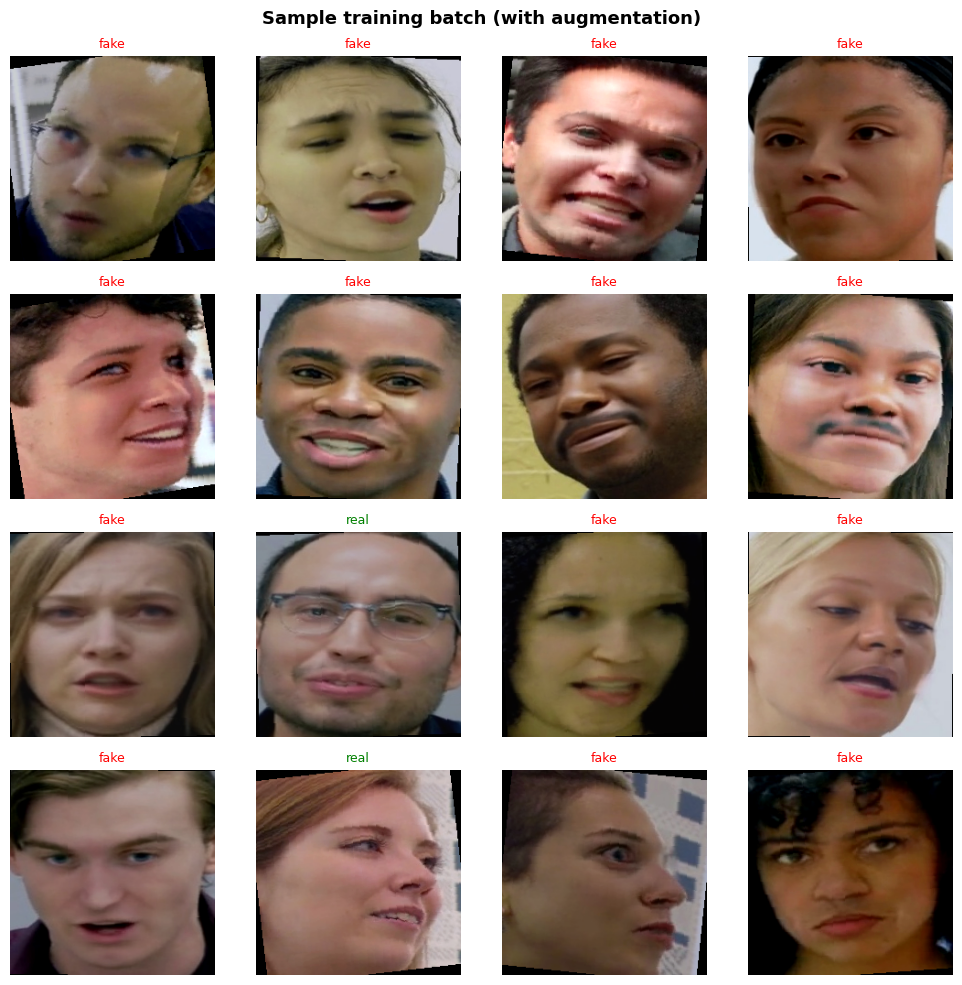

Sample batch image saved.


In [15]:
def denormalise(tensor: torch.Tensor) -> np.ndarray:
    """
    Reverse the ImageNet normalisation so we can display the image.

    After normalisation, pixel values are roughly in [-2, +2].
    We need to convert them back to [0, 255] for display.

    Args:
        tensor: A single image tensor of shape (3, H, W).

    Returns:
        A NumPy array of shape (H, W, 3) with uint8 values in [0, 255].
    """
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    # Reverse the normalisation formula: original = normalised * std + mean
    img = tensor * std + mean

    # Clamp to [0, 1], move channels to the last dimension, convert to uint8
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return (img * 255).astype(np.uint8)


# Show a grid of 16 faces from the training batch
CLASS_NAMES = {v: k for k, v in train_dataset.class_to_idx.items()}
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("Sample training batch (with augmentation)", fontsize=13, fontweight="bold")

for i, ax in enumerate(axes.flat):
    img_np   = denormalise(sample_images[i])
    label_id = sample_labels[i].item()
    ax.imshow(img_np)
    ax.set_title(CLASS_NAMES[label_id], fontsize=9,
                 color="green" if CLASS_NAMES[label_id] == "real" else "red")
    ax.axis("off")

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "sample_training_batch.png"), dpi=150)
plt.show()
print("Sample batch image saved.")

In [16]:
# ── Save dataset config as JSON  ──────────────────────────────────────────────
# This file tells exactly how the data is set up
# so we do not have to guess any settings.

dataset_config = {
    "dataset_dir"   : str(DATASET_DIR),
    "image_size"    : IMAGE_SIZE,
    "batch_size"    : BATCH_SIZE,
    "num_workers"   : NUM_WORKERS,
    "class_to_idx"  : train_dataset.class_to_idx,
    "imagenet_mean" : IMAGENET_MEAN,
    "imagenet_std"  : IMAGENET_STD,
    "split_sizes"   : {
        "train": len(train_dataset),
        "val"  : len(val_dataset),
        "test" : len(test_dataset),
    },
    "label_stats"   : label_stats,
}

config_path = PROJECT_ROOT / "dataset_config.json"
with open(config_path, "w") as f:
    json.dump(dataset_config, f, indent=2)

print(f"Dataset config saved to: {config_path}")
print("\n📋 Config contents:")
print(json.dumps(dataset_config, indent=2))

Dataset config saved to: C:\Users\lulum\Documents\umbc\DATA 621\Final Project\dataset_config.json

📋 Config contents:
{
  "dataset_dir": "C:\\Users\\lulum\\Documents\\umbc\\DATA 621\\Final Project\\04_dataset",
  "image_size": 224,
  "batch_size": 32,
  "num_workers": 0,
  "class_to_idx": {
    "fake": 0,
    "real": 1
  },
  "imagenet_mean": [
    0.485,
    0.456,
    0.406
  ],
  "imagenet_std": [
    0.229,
    0.224,
    0.225
  ],
  "split_sizes": {
    "train": 57501,
    "val": 12141,
    "test": 12410
  },
  "label_stats": {
    "real": {
      "train": 7118,
      "val": 1502,
      "test": 1508
    },
    "fake": {
      "train": 50383,
      "val": 10639,
      "test": 10902
    }
  }
}


In [17]:
# ── Final status printout ─────────────────────────────────────────────────────
print("=" * 50)
print("  Data pipeline work is COMPLETE!")
print("=" * 50)
print()
print("📁 Files ready locally:")
print(f"   {DATASET_DIR}/")
print(f"       train/real/  ({label_stats['real']['train']} images)")
print(f"       train/fake/  ({label_stats['fake']['train']} images)")
print(f"       val/real/    ({label_stats['real']['val']} images)")
print(f"       val/fake/    ({label_stats['fake']['val']} images)")
print(f"       test/real/   ({label_stats['real']['test']} images)")
print(f"       test/fake/   ({label_stats['fake']['test']} images)")
print()
print("📦 Variables ready (run this notebook first):")
print("   train_loader   ← use this in the training loop")
print("   val_loader     ← use this to check validation accuracy")
print("   test_loader    ← use this for final evaluation")
print()
print("Config file: dataset_config.json")

  Data pipeline work is COMPLETE!

📁 Files ready locally:
   C:\Users\lulum\Documents\umbc\DATA 621\Final Project\04_dataset/
       train/real/  (7118 images)
       train/fake/  (50383 images)
       val/real/    (1502 images)
       val/fake/    (10639 images)
       test/real/   (1508 images)
       test/fake/   (10902 images)

📦 Variables ready (run this notebook first):
   train_loader   ← use this in the training loop
   val_loader     ← use this to check validation accuracy
   test_loader    ← use this for final evaluation

Config file: dataset_config.json
